# Avaliação Final — Piloto de Cobrança Preventiva (BemLar)

Este notebook é o **esqueleto** da sua entrega. Os blocos abaixo dizem *o que* precisa ser feito; o código é seu.

Antes de escrever qualquer linha:
1. Leia `00_email_financeiro.md` inteiro.
2. Leia `dicionario.md` inteiro.
3. Abra os cinco CSVs e **olhe os valores**, não só os nomes das colunas.

> A entrega vale mais pelas decisões registradas do que pelo código. Cada bloco marcado com ❓ pede uma resposta escrita — responda em célula markdown, ali mesmo.

---
## Fase 1 — Entendimento do Negócio

❓ Em uma frase, qual é a pergunta de negócio? Qual é a unidade de análise (o que é uma linha)?

❓ O Ricardo fez 5 pedidos no e-mail. Liste os 5 e, para cada um, marque agora sua intenção: **atender**, **atender com ressalva** ou **recusar**. Você pode mudar de ideia depois — mas registre a versão inicial.

**Pergunta de negócio:** quais 80 contratos devem receber uma ligação preventiva por semana,
sete dias antes do vencimento, por apresentarem maior risco de não pagar a parcela
de referência até 30 dias após o vencimento?

**Unidade de análise:** um contrato, associado a uma parcela de referência e a uma
data de previsão; um cliente pode ter mais de um contrato.

### Considerações Iniciais

| Pedido do Ricardo | Intenção inicial | Como pretendemos conduzir |
|---|---|---|
| Obter acurácia acima de 80% | Atender | Buscar esse resultado e calcular a acurácia, sem prometer um valor antes da avaliação. |
| Usar `status_contrato` | Atender com ressalva | Verificar se representa o alvo e se estava disponível na data da previsão. |
| Usar bairro e sexo | Recusar | Não justificar decisões individuais por sexo ou localização residencial; priorizar comportamento financeiro. |
| Usar score de bureau | Atender | Comparar versões com e sem score, nos mesmos dados e cortes, para medir sua contribuição. |
| Usar motivos de atraso | Atender | Investigar os relatos e verificar se podem ser associados aos contratos antes de entrar no modelo. |

Estas são as intenções iniciais solicitadas, preservadas mesmo quando a auditoria
indica uma revisão. As decisões após a preparação aparecem na seção 3.4.

Com capacidade fixa de **80 ligações**, priorizaremos `precision@80`: quantos dos
80 selecionados realmente tiveram o desfecho. Também calcularemos `recall@80`
(parcela dos inadimplentes alcançada) e acurácia global. Um falso positivo ocupa uma
ligação com alguém que pagaria no prazo de D+30; um falso negativo deixa um contrato
de risco fora da fila. A referência de **R$ 1.200 por contrato** quantifica exposição
ao risco, não economia garantida: o efeito da ligação precisa de um piloto com controle.

---
## Fase 2 — Entendimento dos Dados

Carregue os cinco arquivos. Lembre: separador `;`, decimal `,`, datas `dd/mm/aaaa`.

Para **cada** base, responda:
- Qual é a granularidade (o que é uma linha)?
- Quantos contratos ela cobre? Todos, ou só uma parte?
- O que significa um valor vazio nessa base? Sempre a mesma coisa?

❓ Faça um inventário de problemas de qualidade: nulos, valores impossíveis, categorias que deveriam ser a mesma. Registre em uma tabela: problema | onde | quantas linhas | é erro ou artefato | o que você fez.

O roteiro menciona cinco bases, mas há **seis CSVs** quando incluímos os motivos de
atraso. Todos serão inspecionados. Datas são lidas explicitamente no formato brasileiro;
uma data não vazia que não puder ser convertida interrompe a execução.

In [2]:
import pandas as pd
import numpy as np

KW = dict(sep=";", decimal=",", encoding="utf-8")

# TODO: carregar contratos, pagamentos, compras, ocorrencias_sac, score_bureau
# TODO: converter as colunas de data com pd.to_datetime(..., format="%d/%m/%Y")


from pathlib import Path
from IPython.display import display

CAMINHO_DADOS = Path('.')
DATAS = {
    'contratos': ['data_venda', 'data_snapshot'],
    'pagamentos': ['data_vencimento', 'data_pagamento'],
    'compras': ['data_compra'],
    'ocorrencias_sac': ['data_ocorrencia'],
    'score_bureau': ['data_consulta'],
    'motivos_atraso': ['data_registro'],
}

def carregar_bases(caminho_dados):
    bases = {}
    for nome, colunas in DATAS.items():
        df = pd.read_csv(Path(caminho_dados) / f'{nome}.csv', **KW)
        for coluna in colunas:
            df[coluna] = pd.to_datetime(df[coluna], format='%d/%m/%Y', errors='raise')
        bases[nome] = df
    return bases

bases = carregar_bases(CAMINHO_DADOS)
contratos = bases['contratos']
pagamentos = bases['pagamentos']
compras = bases['compras']
sac = bases['ocorrencias_sac']
bureau = bases['score_bureau']
motivos = bases['motivos_atraso']

granularidades = {
    'contratos': 'Um contrato',
    'pagamentos': 'Uma parcela vencida até o snapshot',
    'compras': 'Uma outra compra do cliente',
    'ocorrencias_sac': 'Um atendimento associado ao contrato',
    'score_bureau': 'Uma consulta de score do contrato',
    'motivos_atraso': 'Uma anotação sem identificador de cliente/contrato',
}
resumo = []
for nome, df in bases.items():
    cobertura = (df['id_contrato'].nunique() if 'id_contrato' in df else
                 contratos.loc[contratos['id_cliente'].isin(df['id_cliente']), 'id_contrato'].nunique()
                 if 'id_cliente' in df else pd.NA)
    resumo.append([nome, len(df), granularidades[nome], cobertura])
    print(f'\n{nome}: amostra dos valores')
    display(df.head(3))
    for coluna in df.select_dtypes(include='object'):
        if not coluna.startswith('id_'):
            print(coluna, df[coluna].value_counts(dropna=False).to_dict())
display(pd.DataFrame(resumo, columns=['base', 'linhas', 'granularidade', 'contratos_cobertos_no_snapshot']))
display(pd.concat({nome: df.isna().sum() for nome, df in bases.items()})
        .rename('nulos').to_frame())


contratos: amostra dos valores


,id_contrato,id_cliente,data_venda,loja,canal_venda,valor_total,n_parcelas,valor_parcela,bairro,sexo,idade,renda_declarada,status_contrato,data_snapshot
0,C00001,CLI00533,2025-05-04,Centro,Loja física,1014.95,10,101.50,Jardim América,F,27,6104.01,Quitado,2026-03-15
1,C00003,CLI00116,2025-03-16,Zona Leste,Site,2494.27,12,207.86,Vila Progresso,F,61,3944.55,Quitado,2026-03-15
2,C00004,CLI00930,2024-11-16,Zona Leste,Loja física,1516.74,10,151.67,Alto da Serra,M,39,1492.09,Inadimplente,2026-03-15


loja {'Centro': 942, 'Zona Leste': 874, 'Shopping Norte': 789, 'Online': 395}
canal_venda {'Loja física': 2079, 'Site': 558, 'Televendas': 363}
bairro {'Vila Progresso': 475, 'Jardim América': 429, 'Parque das Flores': 382, 'Centro': 368, 'Bela Vista': 310, 'Cidade Nova': 301, 'Jardim Botânico': 286, 'Jd. America': 232, 'Alto da Serra': 217}
sexo {'F': 1635, 'M': 1365}
status_contrato {'Inadimplente': 1282, 'Em dia': 914, 'Quitado': 804}

pagamentos: amostra dos valores


,id_contrato,n_parcela,data_vencimento,data_pagamento,valor_parcela
0,C00001,1,2025-06-03,2025-06-01,101.5
1,C00001,2,2025-07-03,2025-07-04,101.5
2,C00001,3,2025-08-02,2025-07-27,101.5



compras: amostra dos valores


...

motivo_consulta {'Aprovacao de crediario': 3000, 'Revisao de carteira': 1490}

motivos_atraso: amostra dos valores


,motivo_relatado,data_registro
0,Desemprego,2025-04-15
1,Desemprego / reducao de renda,2025-02-22
2,Outros,2025-10-12


motivo_relatado {'Separacao / divorcio': 76, 'Problemas de saude na familia': 70, 'Desemprego': 67, 'Reducao de renda': 65, 'Problemas de saúde': 65, 'Esqueceu o vencimento': 63, 'Boleto nao chegou': 63, 'Nao recebeu o boleto ': 59, 'Desemprego / reducao de renda': 58, 'Outros': 56, 'Problema de saude': 56, 'Perda de emprego': 56, 'Discordância do valor': 55, 'Nao recebeu o boleto': 55, 'Esquecimento': 54, 'Mudanca de endereco': 51, 'Discordancia do valor': 50}


,base,linhas,granularidade,contratos_cobertos_no_snapshot
0,contratos,3000,Um contrato,3000
1,pagamentos,28861,Uma parcela vencida até o snapshot,3000
2,compras,3983,Uma outra compra do cliente,2621
3,ocorrencias_sac,3446,Um atendimento associado ao contrato,1989
4,score_bureau,4490,Uma consulta de score do contrato,3000
5,motivos_atraso,1019,Uma anotação sem identificador de cliente/cont...,<NA>


nulos
contratos       id_contrato          0
                id_cliente           0
                data_venda           0
                loja                 0
                canal_venda          0
                valor_total          0
                n_parcelas           0
                valor_parcela        0
                bairro               0
                sexo                 0
                idade                0
                renda_declarada      0
                status_contrato      0
                data_snapshot        0
pagamentos      id_contrato          0
                n_parcela            0
                data_vencimento      0
                data_pagamento    1690
                valor_parcela        0
compras         id_cliente           0
                data_compra          0
                valor                0
                categoria            0
ocorrencias_sac id_contrato          0
                data_ocorrencia      0
                tipo_ocorrencia      0
                canal                0
score_bureau    id_contrato          0
                data_consulta        0
                score                0
                motivo_consulta      0
motivos_atraso  motivo_relatado      0
                data_registro        0

### Granularidade, cobertura e significado dos vazios

| Base | Cobertura no snapshot | Significado de vazio ou ausência |
|---|---|---|
| Contratos | 3.000 contratos, 1.824 clientes; todos | Não há nulos. Cadastro vazio seria informação desconhecida, não zero. Renda zero exige tratamento separado. |
| Pagamentos | 28.861 parcelas, todos os 3.000 contratos | As 1.690 datas de pagamento vazias significam parcela ainda não paga no snapshot. Não se deve preencher com uma data inventada. |
| Compras | 3.983 compras de 1.493 clientes, cobrindo 2.621 contratos | Não há nulos. Sem evento observado, contagem e volume são zero; média e recência não são conhecidas. Uma compra pode integrar o histórico de mais de um contrato do cliente. |
| SAC | 3.446 registros, 1.989 contratos | Não há nulos. Sem atendimento observado, frequência é zero; isso não prova que o cliente nunca teve dificuldade. |
| Bureau | 4.490 consultas, todos os 3.000 contratos | Não há nulos. A ausência de consulta válida seria score desconhecido, nunca score zero. Há consultas repetidas por contrato em datas diferentes. |
| Motivos de atraso | 1.019 anotações; cobertura por contrato indeterminável | Não há nulos, mas falta a própria chave. Não é possível inferir quem não relatou motivo nem ligar uma anotação a um contrato. |

Essas coberturas são anteriores ao recorte temporal e não significam que todos os
registros poderão ser usados. A cobertura efetiva será recalculada na fase 3.

In [3]:
# TODO: inventario de qualidade - nulos, impossiveis, categorias quase-duplicadas

problemas = []
def registrar(problema, onde, quantidade, natureza, tratamento):
    problemas.append([problema, onde, int(quantidade), natureza, tratamento])

registrar('Idade acima de 100', 'contratos.idade', contratos['idade'].gt(100).sum(),
          'Suspeita cadastral, não impossibilidade biológica', 'Solicitar validação; idade fora das features desta versão')
registrar('Renda igual a zero', 'contratos.renda_declarada', contratos['renda_declarada'].eq(0).sum(),
          'Ambíguo: renda efetiva ou falta de preenchimento', 'Na preparação: NaN e indicador de renda ausente; não dividir por zero')
registrar('Abreviação Jd. America', 'contratos.bairro', contratos['bairro'].eq('Jd. America').sum(),
          'Provável variação de Jardim América (429 linhas)', 'Mapear apenas na cópia para diagnóstico; bairro fora do modelo')
registrar('Duplicata exata', 'ocorrencias_sac', sac.duplicated().sum(),
          'Provável repetição da extração', 'Remover excedentes na preparação; hipótese documentada pois não há ID do atendimento')
registrar('Duplicata aparente', 'motivos_atraso', motivos.duplicated().sum(),
          'Indeterminado sem chave: relatos distintos podem coincidir', 'Preservar; não usar como feature')
registrar('Sem chave de contrato/cliente', 'motivos_atraso', len(motivos),
          'Limitação estrutural', 'Solicitar nova extração com chave e datas do registro e do evento')
registrar('Data de pagamento vazia', 'pagamentos.data_pagamento', pagamentos['data_pagamento'].isna().sum(),
          'Artefato: parcela não paga até o snapshot', 'Preservar NaT; reconstruir estado na data de previsão')
registrar('Espaços no final do relato', 'motivos_atraso.motivo_relatado',
          motivos['motivo_relatado'].ne(motivos['motivo_relatado'].str.strip()).sum(),
          'Padronização textual', 'Aplicar strip apenas em cópia exploratória; não associar relatos por semelhança')
registrar('Datas inválidas não vazias', 'Todas as bases', 0,
          'Não encontrado: conversão estrita concluída', 'Manter validação na leitura')
registrar('Parcela repetida (chave composta)', 'pagamentos',
          pagamentos.duplicated(['id_contrato', 'n_parcela']).sum(), 'Não encontrado', 'Validar unicidade')
for nome in ['pagamentos', 'ocorrencias_sac', 'score_bureau']:
    registrar('Chave órfã', nome, (~bases[nome]['id_contrato'].isin(contratos['id_contrato'])).sum(),
              'Não encontrado', 'Validar ligação por contrato')
registrar('Chave órfã', 'compras', (~compras['id_cliente'].isin(contratos['id_cliente'])).sum(),
          'Não encontrado', 'Validar ligação por cliente')
valores = pagamentos.merge(contratos[['id_contrato', 'valor_parcela']], on='id_contrato',
                           suffixes=('_pagamento', '_contrato'), validate='many_to_one')
registrar('Valor da parcela divergente', 'pagamentos × contratos',
          (~np.isclose(valores['valor_parcela_pagamento'], valores['valor_parcela_contrato'], atol=0.01)).sum(),
          'Não encontrado', 'Comparar com tolerância de um centavo')
registrar('Score fora de 0–1000', 'score_bureau.score', (~bureau['score'].between(0, 1000)).sum(),
          'Não encontrado', 'Validar domínio')
inventario_qualidade = pd.DataFrame(problemas, columns=['problema', 'onde', 'quantas_linhas', 'erro_ou_artefato', 'o_que_foi_feito'])
display(inventario_qualidade)

contratos_diagnostico = contratos.assign(bairro=contratos['bairro'].replace({'Jd. America': 'Jardim América'}))
motivos_diagnostico = motivos.assign(motivo_relatado=motivos['motivo_relatado'].str.strip())
assert contratos['id_contrato'].is_unique
assert not pagamentos.duplicated(['id_contrato', 'n_parcela']).any()
assert pagamentos[['id_contrato', 'data_vencimento']].notna().all().all()

,problema,onde,quantas_linhas,erro_ou_artefato,o_que_foi_feito
0,Idade acima de 100,contratos.idade,3,"Suspeita cadastral, não impossibilidade biológica",Solicitar validação; idade fora das features d...
1,Renda igual a zero,contratos.renda_declarada,4,Ambíguo: renda efetiva ou falta de preenchimento,Na preparação: NaN e indicador de renda ausent...
2,Abreviação Jd. America,contratos.bairro,232,Provável variação de Jardim América (429 linhas),Mapear apenas na cópia para diagnóstico; bairr...
3,Duplicata exata,ocorrencias_sac,2,Provável repetição da extração,Remover excedentes na preparação; hipótese doc...
4,Duplicata aparente,motivos_atraso,78,Indeterminado sem chave: relatos distintos pod...,Preservar; não usar como feature
5,Sem chave de contrato/cliente,motivos_atraso,1019,Limitação estrutural,Solicitar nova extração com chave e datas do r...
6,Data de pagamento vazia,pagamentos.data_pagamento,1690,Artefato: parcela não paga até o snapshot,Preservar NaT; reconstruir estado na data de p...
7,Espaços no final do relato,motivos_atraso.motivo_relatado,59,Padronização textual,Aplicar strip apenas em cópia exploratória; nã...
8,Datas inválidas não vazias,Todas as bases,0,Não encontrado: conversão estrita concluída,Manter validação na leitura
9,Parcela repetida (chave composta),pagamentos,0,Não encontrado,Validar unicidade


As idades suspeitas são **108, 137 e 108 anos**; ficam fora do modelo, sem excluir
os contratos. Há também sinônimos nos relatos (por exemplo, “Perda de emprego” e
“Desemprego”), mas não os fundimos automaticamente: os textos podem representar
situações distintas. A inspeção de categorias é descritiva; não transforma sexo,
bairro ou relatos sensíveis em variáveis de previsão. Os CSVs originais são preservados.

---
## Fase 3 — Preparação dos Dados

### 3.1 Construir o alvo

A regra está no enunciado e no dicionário. Você precisa, para cada contrato:
1. identificar a **parcela de referência**;
2. calcular a **data de referência**;
3. derivar `inadimplente_30d`.

❓ Depois de construir: qual é a prevalência de positivos? Ela é compatível com o que o Ricardo descreveu no e-mail?

❓ Compare o seu alvo com `status_contrato`. Eles concordam? Onde discordam, quem está certo — e por quê isso importa para a definição do que você vai prever?

Selecionamos, por contrato, a última parcela com vencimento até **snapshot − 30 dias**.
Como o snapshot é 15/03/2026, o limite é 13/02/2026. A previsão ocorre em
**vencimento − 7 dias para todos os contratos**, conforme o dicionário.

O enunciado propõe usar o snapshot para contratos em dia, o que conflita com essa
regra. Adotar datas diferentes em função do resultado usaria informação futura e
permitiria observar o próprio desfecho de alguns contratos. Registramos, portanto,
a escolha uniforme do dicionário como pressuposto a validar com o responsável.

O alvo vale 1 se o pagamento está vazio ou ocorreu **depois de D+30**, e 0 se ocorreu
até D+30, inclusive. Dados posteriores à previsão são usados somente para observar
o alvo, nunca para construir as features.

In [4]:
# TODO: identificar a parcela de referencia por contrato
# TODO: calcular data_referencia
# TODO: construir inadimplente_30d

def construir_alvo(contratos, pagamentos):
    parcelas = pagamentos.merge(contratos[['id_contrato', 'data_snapshot']],
                                 on='id_contrato', validate='many_to_one')
    elegiveis = parcelas.loc[parcelas['data_vencimento'].le(
        parcelas['data_snapshot'] - pd.Timedelta(days=30))].copy()
    referencia = (elegiveis.sort_values(['id_contrato', 'data_vencimento', 'n_parcela'])
                 .drop_duplicates('id_contrato', keep='last').copy())
    referencia['data_referencia'] = referencia['data_vencimento'] - pd.Timedelta(days=7)
    referencia['inadimplente_30d'] = (
        referencia['data_pagamento'].isna() |
        referencia['data_pagamento'].gt(referencia['data_vencimento'] + pd.Timedelta(days=30))
    ).astype('int64')
    assert set(referencia['id_contrato']) == set(contratos['id_contrato'])
    assert referencia['id_contrato'].is_unique
    return referencia[['id_contrato', 'n_parcela', 'data_vencimento',
                       'data_referencia', 'inadimplente_30d']].rename(columns={
                           'n_parcela': 'n_parcela_referencia',
                           'data_vencimento': 'vencimento_referencia'})

alvo = construir_alvo(contratos, pagamentos)
datas_referencia = alvo[['id_contrato', 'data_referencia']].copy()
print(f"Contratos: {len(alvo):,}; positivos: {alvo['inadimplente_30d'].sum():,}; "
      f"prevalência: {alvo['inadimplente_30d'].mean():.2%}")
comparacao_status = contratos[['id_contrato', 'status_contrato', 'sexo']].merge(alvo, on='id_contrato')
display(pd.crosstab(comparacao_status['status_contrato'], comparacao_status['inadimplente_30d']))
divergencias = comparacao_status['status_contrato'].eq('Inadimplente').astype(int).ne(comparacao_status['inadimplente_30d'])
print('Divergências com status Inadimplente:', divergencias.sum())
display(comparacao_status.groupby('sexo')['inadimplente_30d'].agg(['count', 'sum', 'mean']))

Contratos: 3,000; positivos: 1,300; prevalência: 43.33%


inadimplente_30d,0,1
status_contrato,,
Em dia,896,18
Inadimplente,22,1260
Quitado,782,22


Divergências com status Inadimplente: 62


,count,sum,mean
sexo,,,
F,1635,707,0.432416
M,1365,593,0.434432


**Prevalência:** 1.300 de 3.000 contratos, ou **43,3%**, tiveram a parcela de referência
não paga até D+30; 1.700 não tiveram esse desfecho. É uma proporção relevante e
compatível com a preocupação financeira, mas o e-mail não apresenta uma taxa de
referência para afirmar que o número confirma o relato sobre perdas anuais.
Essa amostra histórica também não define a taxa de uma semana futura.

**Status versus alvo:** ao traduzir `Inadimplente` para 1 e os demais status para 0,
há **62 divergências**: 22 contratos classificados como inadimplentes no snapshot
não tiveram esse desfecho na parcela escolhida; outros 18 “Em dia” e 22 “Quitado”
tiveram o desfecho histórico. Para a pergunta deste projeto, prevalece o alvo calculado
com as datas da parcela. Estar quitado em março não desfaz um pagamento ocorrido
depois de D+30 no passado. Não marcamos “Quitado” automaticamente como 1 nem
usamos o status atual para reescrever o resultado histórico.

O status foi observado em **15/03/2026**, depois de todas as datas de previsão,
e mede outra situação. Por isso, ele sai das features.

Na análise agregada, a taxa é **43,24% para F** e **43,44% para M**. Os dados não
sustentam a alegação geral de maior atraso feminino; essa comparação simples
também não constitui teste causal nem valida alegações sobre subgrupos territoriais.
A exclusão de sexo e bairro independe de obter ou não ganho de métrica.

### 3.2 A função de corte temporal

Está pronta. Use em **toda** base de eventos antes de agregar qualquer coisa.

In [5]:
def filtra_por_data(df_eventos, chave, col_data, datas_ref, col_ref="data_referencia"):
    """Mantem apenas os eventos ocorridos ATE a data de referencia de cada contrato.

    df_eventos : DataFrame de eventos (pagamentos, sac, compras, consultas...)
    chave      : coluna de juncao com datas_ref (ex.: "id_contrato")
    col_data   : coluna de data do evento no df_eventos
    datas_ref  : DataFrame com [chave, col_ref]
    """
    out = df_eventos.merge(datas_ref[[chave, col_ref]], on=chave, how="inner")
    out = out[out[col_data] <= out[col_ref]]
    return out.drop(columns=[col_ref])


O corte é inclusivo (`evento <= data_referencia`), pois só temos datas, sem horários.
Assumimos que os registros do dia já estavam disponíveis quando a previsão é feita.
Para produção, será necessário confirmar horário de disponibilização e possíveis
atrasos de registro em cada sistema.

### 3.3 Construir as features

Uma linha por contrato. Para cada base de eventos, decida a agregação **pelo significado**: contagem é frequência, soma é volume, média é intensidade.

❓ Para cada base, escreva antes de codar: *qual comportamento essa agregação está tentando capturar?*

❓ Ausência de evento vira 0, nulo, ou mediana? A resposta é a mesma para toda coluna?

Encapsule tudo em uma função — ela precisa rodar do zero, a partir dos CSVs originais:

```python
def construir_features(caminho_dados, datas_referencia):
    ...
    return df
```

### O que cada agregação representa

| Origem | Agregações planejadas | Comportamento ou condição capturada | Ausência de histórico |
|---|---|---|---|
| Contratos | Valores contratados, prazo, renda válida, parcela/renda, tempo desde a venda | Compromisso financeiro e tempo de relacionamento contratual | Renda não positiva vira nulo e indicador; demais campos são validados. |
| Pagamentos | Quantidade de parcelas já vencidas, proporção com atraso, atraso médio e máximo, quantidade/valor em aberto | Regularidade de pagamento conhecida na previsão | Contagens e soma em aberto = 0; proporção e atrasos médio/máximo = nulo quando não há parcelas anteriores. |
| Compras | Contagem, soma, média e dias desde a última compra anterior | Frequência, volume, intensidade e recência de outras compras | Contagem e soma = 0; média e recência = nulo. |
| SAC | Quantidade de atendimentos, de pedidos de boleto e de negociações; recência | Frequência de contato e sinais de dificuldade operacional/financeira | Contagens = 0; recência = nulo. |
| Bureau | Último score disponível até a previsão | Avaliação externa de risco já conhecida | Score = nulo se não houver consulta; nunca zero. |
| Motivos de atraso | Nenhuma agregação por contrato | Não há chave para associar relatos com segurança | Não inferir associação por data, ordem das linhas ou texto. |

**Cuidado com pagamentos:** filtramos as parcelas vencidas antes da previsão e,
separadamente, os pagamentos que já eram conhecidos. Se uma parcela só foi paga
depois da previsão, ela é tratada como aberta naquela data; seu atraso é contado
somente até a data de referência. Um pagamento posterior não pode “curar” o histórico
que o modelo teria visto antes. A parcela que define o alvo não entra no histórico.

As bases são agregadas para uma linha por contrato antes da junção final. Compras
são ligadas por cliente e depois filtradas pela data específica de cada contrato.
Não usamos uma única data de corte por cliente.

Não imputaremos medianas nesta fase: elas deverão ser aprendidas **apenas no treino**
na fase 4. O conjunto com bureau conterá `score_bureau`; o conjunto sem bureau
retirará essa coluna. O algoritmo, os contratos e os cortes de avaliação deverão
ser os mesmos para isolar a contribuição do score.

In [6]:
# TODO: construir_features()

def construir_features(caminho_dados, datas_referencia):
    """Lê os CSVs originais e retorna uma linha por contrato, com alvo e histórico temporal."""
    dados = carregar_bases(caminho_dados)
    c, p = dados['contratos'], dados['pagamentos']
    a = construir_alvo(c, p)
    refs = datas_referencia[['id_contrato', 'data_referencia']].copy()
    refs['data_referencia'] = pd.to_datetime(refs['data_referencia'])
    assert refs['id_contrato'].is_unique and refs.notna().all().all()
    assert set(refs['id_contrato']) == set(c['id_contrato'])
    conferencia = a.merge(refs, on='id_contrato', suffixes=('_calculada', '_informada'), validate='one_to_one')
    assert conferencia['data_referencia_calculada'].eq(conferencia['data_referencia_informada']).all()

    cadastro = c.merge(refs, on='id_contrato', validate='one_to_one')
    assert cadastro['data_venda'].le(cadastro['data_referencia']).all()
    assert c[['valor_total', 'valor_parcela', 'n_parcelas']].gt(0).all().all()
    f = cadastro[['id_contrato', 'valor_total', 'n_parcelas', 'valor_parcela']].copy()
    f['renda_declarada'] = cadastro['renda_declarada'].where(cadastro['renda_declarada'].gt(0))
    f['renda_ausente'] = f['renda_declarada'].isna().astype(int)
    f['parcela_sobre_renda'] = f['valor_parcela'] / f['renda_declarada']
    f['tempo_contrato_dias'] = (cadastro['data_referencia'] - cadastro['data_venda']).dt.days
    f = f.merge(a[['id_contrato', 'data_referencia', 'inadimplente_30d']], on='id_contrato', validate='one_to_one')

    # Vencimentos e pagamentos têm cortes independentes: pagar no futuro não altera o passado.
    vencidas = filtra_por_data(p, 'id_contrato', 'data_vencimento', refs)
    conhecidos = filtra_por_data(p.loc[p['data_pagamento'].notna()], 'id_contrato', 'data_pagamento', refs)
    hist = vencidas.drop(columns='data_pagamento').merge(
        conhecidos[['id_contrato', 'n_parcela', 'data_pagamento']],
        on=['id_contrato', 'n_parcela'], how='left', validate='one_to_one').merge(
            refs, on='id_contrato', validate='many_to_one')
    hist['em_aberto'] = hist['data_pagamento'].isna().astype(int)
    fim = hist['data_pagamento'].fillna(hist['data_referencia'])
    hist['atraso_dias'] = (fim - hist['data_vencimento']).dt.days.clip(lower=0)
    hist['teve_atraso'] = hist['atraso_dias'].gt(0).astype(int)
    hist['valor_aberto'] = hist['valor_parcela'] * hist['em_aberto']
    assert hist['data_vencimento'].le(hist['data_referencia']).all()
    assert (hist['data_pagamento'].isna() | hist['data_pagamento'].le(hist['data_referencia'])).all()
    pag_agg = hist.groupby('id_contrato').agg(
        qtd_parcelas_anteriores=('n_parcela', 'size'),
        proporcao_atrasos_anteriores=('teve_atraso', 'mean'),
        atraso_medio_anterior_dias=('atraso_dias', 'mean'),
        atraso_maximo_anterior_dias=('atraso_dias', 'max'),
        qtd_parcelas_em_aberto=('em_aberto', 'sum'),
        valor_parcelas_em_aberto=('valor_aberto', 'sum'))
    f = f.merge(pag_agg, on='id_contrato', how='left', validate='one_to_one')

    compras_contrato = dados['compras'].merge(c[['id_cliente', 'id_contrato']], on='id_cliente', validate='many_to_many')
    compras_hist = filtra_por_data(compras_contrato, 'id_contrato', 'data_compra', refs)
    compras_agg = compras_hist.groupby('id_contrato').agg(
        qtd_compras_anteriores=('valor', 'size'), valor_compras_anteriores=('valor', 'sum'),
        valor_medio_compras_anteriores=('valor', 'mean'), ultima_compra=('data_compra', 'max'))
    f = f.merge(compras_agg, on='id_contrato', how='left', validate='one_to_one')
    f['dias_desde_ultima_compra'] = (f['data_referencia'] - f.pop('ultima_compra')).dt.days

    sac_limpo = dados['ocorrencias_sac'].drop_duplicates()
    sac_hist = filtra_por_data(sac_limpo, 'id_contrato', 'data_ocorrencia', refs)
    sac_hist['segunda_via'] = sac_hist['tipo_ocorrencia'].eq('Segunda via de boleto').astype(int)
    sac_hist['negociacao'] = sac_hist['tipo_ocorrencia'].eq('Negociacao de divida').astype(int)
    sac_agg = sac_hist.groupby('id_contrato').agg(
        qtd_atendimentos_sac=('data_ocorrencia', 'size'), qtd_segunda_via=('segunda_via', 'sum'),
        qtd_negociacoes=('negociacao', 'sum'), ultimo_sac=('data_ocorrencia', 'max'))
    f = f.merge(sac_agg, on='id_contrato', how='left', validate='one_to_one')
    f['dias_desde_ultimo_sac'] = (f['data_referencia'] - f.pop('ultimo_sac')).dt.days

    score_hist = filtra_por_data(dados['score_bureau'], 'id_contrato', 'data_consulta', refs)
    assert score_hist['score'].between(0, 1000).all()
    # Não escolhemos pela categoria aprovação/revisão: o critério de elegibilidade é a data.
    ultimo_score = (score_hist.sort_values(['id_contrato', 'data_consulta'])
                   .drop_duplicates('id_contrato', keep='last')[['id_contrato', 'score']]
                   .rename(columns={'score': 'score_bureau'}))
    f = f.merge(ultimo_score, on='id_contrato', how='left', validate='one_to_one')

    contagens = ['qtd_parcelas_anteriores', 'qtd_parcelas_em_aberto', 'qtd_compras_anteriores',
                'qtd_atendimentos_sac', 'qtd_segunda_via', 'qtd_negociacoes']
    somas = ['valor_parcelas_em_aberto', 'valor_compras_anteriores']
    f[contagens] = f[contagens].fillna(0).astype(int)
    f[somas] = f[somas].fillna(0)
    assert len(f) == len(c) and f['id_contrato'].is_unique
    assert not np.isinf(f.select_dtypes(include='number').to_numpy()).any()
    assert f['inadimplente_30d'].isin([0, 1]).all()

    auditoria_temporal = []
    for nome, antes, depois, coluna in [
        ('Parcelas vencidas', p, vencidas, 'data_vencimento'),
        ('Pagamentos conhecidos', p.loc[p['data_pagamento'].notna()], conhecidos, 'data_pagamento'),
        ('Compras ligadas por contrato', compras_contrato, compras_hist, 'data_compra'),
        ('SAC sem duplicatas', sac_limpo, sac_hist, 'data_ocorrencia'),
        ('Bureau', dados['score_bureau'], score_hist, 'data_consulta'),
    ]:
        check = depois.merge(refs, on='id_contrato', validate='many_to_one')
        assert check[coluna].le(check['data_referencia']).all()
        auditoria_temporal.append({'base': nome, 'eventos_antes': len(antes), 'eventos_validos': len(depois),
                                  'eventos_excluidos': len(antes) - len(depois),
                                  'contratos_com_evento_valido': depois['id_contrato'].nunique()})
    f = f.sort_values('id_contrato').reset_index(drop=True)
    f.attrs['auditoria_temporal'] = auditoria_temporal
    return f

features = construir_features(CAMINHO_DADOS, datas_referencia)
display(features.head())
display(pd.DataFrame(features.attrs['auditoria_temporal']))
display(features.isna().sum().rename('nulos_preservados').to_frame())

,id_contrato,valor_total,n_parcelas,valor_parcela,renda_declarada,renda_ausente,parcela_sobre_renda,tempo_contrato_dias,data_referencia,inadimplente_30d,...,valor_parcelas_em_aberto,qtd_compras_anteriores,valor_compras_anteriores,valor_medio_compras_anteriores,dias_desde_ultima_compra,qtd_atendimentos_sac,qtd_segunda_via,qtd_negociacoes,dias_desde_ultimo_sac,score_bureau
0,C00001,1014.95,10,101.50,6104.01,0,0.016628,263,2026-01-22,0,...,0.0,6,4798.72,799.786667,51.0,1,1,0,59.0,600
1,C00003,2494.27,12,207.86,3944.55,0,0.052695,323,2026-02-02,0,...,0.0,0,0.00,NaN,NaN,1,0,0,164.0,878
2,C00004,1516.74,10,151.67,1492.09,0,0.101649,293,2025-09-05,1,...,0.0,2,1176.42,588.210000,150.0,0,0,0,NaN,689
3,C00005,9349.93,12,779.16,2230.13,0,0.349379,353,2025-09-03,1,...,0.0,5,3037.25,607.450000,12.0,1,1,0,178.0,594
4,C00007,1974.40,12,164.53,1861.14,0,0.088403,263,2026-01-29,1,...,0.0,4,2131.99,532.997500,68.0,0,0,0,NaN,518


,base,eventos_antes,eventos_validos,eventos_excluidos,contratos_com_evento_valido
0,Parcelas vencidas,28861,24141,4720,3000
1,Pagamentos conhecidos,27171,24033,3138,3000
2,Compras ligadas por contrato,8191,7344,847,2565
3,SAC sem duplicatas,3444,2468,976,1586
4,Bureau,4490,3000,1490,3000


,nulos_preservados
id_contrato,0
valor_total,0
n_parcelas,0
valor_parcela,0
renda_declarada,4
renda_ausente,0
parcela_sobre_renda,4
tempo_contrato_dias,0
data_referencia,0
inadimplente_30d,0


Após o corte, há compras anteriores para **2.565 contratos** e SAC anterior para
**1.586 contratos**. As contagens de compras na auditoria são pares compra–contrato,
pois cada contrato de um mesmo cliente tem sua própria data de referência.

Das consultas de bureau, **3.000 são temporalmente válidas** e **1.490 ficam de fora**.
Nesta extração, as válidas são as consultas de aprovação e as excluídas são revisões
de carteira. A função usa a data, não o rótulo do motivo, para decidir elegibilidade.
O efeito do score será medido posteriormente; não reaproveitamos métricas do
protótipo diagnóstico como se fossem resultados deste notebook.

### 3.4 Auditoria de colunas

Antes de fechar o `features.csv`, passe **cada coluna** pelas três perguntas:

1. **Essa informação existiria no momento em que a previsão seria feita?**
2. **É uma variável protegida ou sensível?**
3. **Descreve comportamento, ou só descreve quem a pessoa é?**

❓ Monte a tabela: coluna | decisão (entra / sai) | justificativa. Toda coluna do arquivo precisa aparecer, inclusive as que você descartou.

Salve o resultado em `features.csv`.

### Decisões após a preparação dos dados

| Pedido | Decisão nesta versão | Justificativa e alternativa |
|---|---|---|
| Acurácia acima de 80% | Atender parcialmente | Calcular e reportar na avaliação, mas selecionar pela `precision@80`, acompanhada de `recall@80` e comparação com fila-base. Não garantir um resultado ainda não medido. |
| `status_contrato` | Recusar | Snapshot posterior à previsão e definição diferente do alvo; usar o desfecho da parcela até D+30 e histórico anterior. |
| Bairro e sexo | Recusar | Risco de tratamento discriminatório e ausência de justificativa para a priorização individual. Usar diagnóstico agregado e avaliar disparidades, sem incorporá-los ao ranking. |
| Score de bureau | Atender parcialmente | Somente consultas disponíveis até a previsão; planejar comparação controlada com e sem score na fase 4. |
| Motivos de atraso | Recusar como feature na versão atual | Falta chave para associação. Solicitar `id_contrato`, data de registro e data do evento; depois revisar disponibilidade temporal e conteúdo sensível antes de qualquer uso. |

**Registro de revisão no CRISP-DM:** o entendimento e a preparação dos dados
alteraram as intenções iniciais sobre status e motivos; a meta de acurácia foi
reposicionada frente à capacidade de 80 ligações. Ainda não houve retorno da
modelagem para a preparação, pois a modelagem está fora deste escopo.

O cadastro é assumido como informação da contratação: valores e prazo são condições
contratuais e a renda foi declarada na aprovação, segundo o dicionário. Não há
histórico de alterações cadastrais para verificar essa hipótese; ela deve ser
confirmada antes de produção. Excluímos também idade, loja e canal de venda nesta
versão para concentrar o piloto em comportamento e compromisso financeiro, evitando
introduzir localização da loja como substituto de bairro. Isso não garante, por si
só, ausência de disparidades nas demais variáveis, inclusive no score externo.

As tabelas abaixo cobrem **todas as colunas das seis fontes** e **todas as colunas
do arquivo final**. “Entra na preparação” não significa que o campo bruto entra
no modelo: chaves e datas servem para ligação, recorte e auditoria.

In [7]:
# TODO: auditoria + gravar features.csv

# Auditoria das colunas de origem: temporalidade, sensibilidade e papel.
auditoria_origem = []
for nome, df in bases.items():
    for coluna in df.columns:
        if nome == 'motivos_atraso':
            decisao, tempo, sensivel, papel = ('Sai', 'Não verificável por contrato',
                'Texto pode revelar saúde e outros dados sensíveis', 'Sem chave: somente diagnóstico da fonte')
        elif coluna in ['sexo', 'bairro', 'idade', 'loja', 'canal_venda', 'status_contrato']:
            motivos_exclusao = {
                'sexo': ('Sem histórico cadastral', 'Característica protegida', 'Quem a pessoa é; sem justificativa operacional'),
                'bairro': ('Sem histórico cadastral', 'Localização e possível proxy socioeconômico', 'Onde mora; risco de discriminação territorial'),
                'idade': ('Data de cálculo não documentada', 'Dado demográfico', 'Não selecionada; três valores suspeitos'),
                'loja': ('Conhecida na venda', 'Pode representar localização', 'Não selecionada para este piloto'),
                'canal_venda': ('Conhecido na venda', 'Pode refletir acesso a canais', 'Não selecionado; priorizar histórico financeiro'),
                'status_contrato': ('Posterior à previsão', 'Situação financeira', 'Vazamento temporal e conceito diferente do alvo'),
            }
            decisao = 'Sai'
            tempo, sensivel, papel = motivos_exclusao[coluna]
        elif coluna.startswith('id_'):
            decisao, tempo, sensivel, papel = ('Entra na preparação', 'Chave do registro',
                'Identificador', 'Ligação/rastreabilidade; nunca preditor')
        elif coluna == 'data_snapshot':
            decisao, tempo, sensivel, papel = ('Entra na preparação', 'Posterior à previsão',
                'Não diretamente', 'Somente fechar janela de observação do alvo')
        elif coluna.startswith('data_'):
            decisao, tempo, sensivel, papel = ('Entra na preparação', 'Evento filtrado por data; venda anterior validada',
                'Pode descrever atividade financeira', 'Corte/recência; datas futuras de pagamento somente no alvo')
        elif nome == 'contratos':
            decisao, tempo, sensivel, papel = ('Entra', 'Assumido disponível na contratação/aprovação',
                'Dado financeiro pessoal', 'Compromisso contratual/capacidade declarada; renda inválida vira nulo')
        elif nome == 'pagamentos':
            decisao, tempo, sensivel, papel = ('Entra na preparação', 'Histórico reconstruído na previsão',
                'Dado financeiro pessoal', 'Identificar parcela e agregar comportamento; referência somente para alvo')
        elif nome == 'compras' and coluna == 'valor':
            decisao, tempo, sensivel, papel = ('Entra na preparação', 'Compra até a previsão',
                'Dado de consumo', 'Agregar volume e intensidade de compras')
        elif nome == 'ocorrencias_sac' and coluna == 'tipo_ocorrencia':
            decisao, tempo, sensivel, papel = ('Entra na preparação', 'Atendimento até a previsão',
                'Pode descrever dificuldade financeira', 'Contar segunda via e negociação; não usar texto livre')
        elif nome == 'score_bureau' and coluna == 'score':
            decisao, tempo, sensivel, papel = ('Entra com ressalva', 'Última consulta até a previsão',
                'Dado financeiro; possível viés externo', 'Avaliação de risco externa; comparar versão sem bureau')
        else:
            decisao, tempo, sensivel, papel = ('Sai', 'Verificável pela data do evento',
                'Depende do contexto', 'Categoria/canal/motivo não selecionado; usado apenas para inspecionar a fonte')
        auditoria_origem.append([f'{nome}.{coluna}', decisao, tempo, sensivel, papel])
auditoria_origem = pd.DataFrame(auditoria_origem, columns=[
    'coluna', 'decisao', 'existiria_na_previsao', 'protegida_ou_sensivel', 'justificativa_e_significado'])

justificativas = {
    'id_contrato': 'Chave para fila e rastreabilidade; não usar como preditor.',
    'data_referencia': 'Controle do corte temporal e do split; não usar como preditor.',
    'inadimplente_30d': 'Alvo observado depois da previsão; nunca incluir em X.',
    'valor_total': 'Compromisso financeiro assumido na contratação.',
    'n_parcelas': 'Prazo contratado, conhecido na venda.',
    'valor_parcela': 'Obrigação periódica conhecida na contratação.',
    'renda_declarada': 'Capacidade declarada na aprovação; não positiva vira nulo.',
    'renda_ausente': 'Indica renda não positiva/desconhecida, sem inventar capacidade financeira.',
    'parcela_sobre_renda': 'Comprometimento declarado com esta parcela; não mede todas as dívidas.',
    'tempo_contrato_dias': 'Tempo desde a venda até a previsão.',
    'qtd_parcelas_anteriores': 'Quantidade de parcelas vencidas até a previsão.',
    'proporcao_atrasos_anteriores': 'Frequência relativa de atraso observável; nulo sem histórico.',
    'atraso_medio_anterior_dias': 'Intensidade média do atraso já observado; nulo sem histórico.',
    'atraso_maximo_anterior_dias': 'Maior atraso já observado, limitado ao conhecimento na previsão.',
    'qtd_parcelas_em_aberto': 'Parcelas vencidas sem pagamento conhecido na previsão.',
    'valor_parcelas_em_aberto': 'Soma das parcelas abertas, sem juros ou multas presumidos.',
    'qtd_compras_anteriores': 'Frequência de outras compras anteriores do cliente.',
    'valor_compras_anteriores': 'Volume financeiro de outras compras anteriores.',
    'valor_medio_compras_anteriores': 'Intensidade média das compras; nulo sem evento.',
    'dias_desde_ultima_compra': 'Recência das compras anteriores; nulo sem evento.',
    'qtd_atendimentos_sac': 'Frequência de atendimento anterior, sem duplicatas exatas.',
    'qtd_segunda_via': 'Frequência de dificuldade operacional com boleto.',
    'qtd_negociacoes': 'Frequência de negociação anterior, sem observar negociações futuras.',
    'dias_desde_ultimo_sac': 'Recência do atendimento anterior; nulo sem evento.',
    'score_bureau': 'Última avaliação externa conhecida; retirar na variante sem bureau.',
}
CONTROLE = ['id_contrato', 'data_referencia', 'inadimplente_30d']
assert set(features.columns) == set(justificativas)
auditoria_features = pd.DataFrame([
    {'coluna': coluna,
     'decisao': 'Entra no arquivo; sai dos preditores' if coluna in CONTROLE else 'Entra como preditor candidato',
     'existiria_na_previsao': 'Não; somente alvo' if coluna == 'inadimplente_30d' else 'Sim, sob hipóteses e cortes documentados',
     'protegida_ou_sensivel': 'Identificação/controle' if coluna in CONTROLE else 'Financeira/comportamental; avaliar disparidades',
     'justificativa': justificativas[coluna]}
    for coluna in features.columns
])
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(auditoria_origem)
    display(auditoria_features)

PREDITORES_COM_BUREAU = [coluna for coluna in features if coluna not in CONTROLE]
PREDITORES_SEM_BUREAU = [coluna for coluna in PREDITORES_COM_BUREAU if coluna != 'score_bureau']
assert not {'sexo', 'bairro', 'idade', 'loja', 'status_contrato', 'id_cliente'}.intersection(features.columns)
assert not set(CONTROLE).intersection(PREDITORES_COM_BUREAU)
assert set(PREDITORES_COM_BUREAU) - set(PREDITORES_SEM_BUREAU) == {'score_bureau'}

# Mesmo formato regional das fontes; campos vazios preservam valores desconhecidos.
features.to_csv(CAMINHO_DADOS / 'features.csv', index=False, sep=';', decimal=',',
                encoding='utf-8', date_format='%d/%m/%Y')
releitura = pd.read_csv(CAMINHO_DADOS / 'features.csv', **KW)
assert len(releitura) == len(contratos) and releitura['id_contrato'].is_unique
assert releitura['inadimplente_30d'].sum() == alvo['inadimplente_30d'].sum()
print(f'features.csv salvo: {features.shape[0]} contratos e {features.shape[1]} colunas.')
print(f'Preditores candidatos: {len(PREDITORES_COM_BUREAU)} com bureau; {len(PREDITORES_SEM_BUREAU)} sem bureau.')

,coluna,decisao,existiria_na_previsao,protegida_ou_sensivel,justificativa_e_significado
0,contratos.id_contrato,Entra na preparação,Chave do registro,Identificador,Ligação/rastreabilidade; nunca preditor
1,contratos.id_cliente,Entra na preparação,Chave do registro,Identificador,Ligação/rastreabilidade; nunca preditor
2,contratos.data_venda,Entra na preparação,Evento filtrado por data; venda anterior validada,Pode descrever atividade financeira,Corte/recência; datas futuras de pagamento somente no alvo
3,contratos.loja,Sai,Conhecida na venda,Pode representar localização,Não selecionada para este piloto
4,contratos.canal_venda,Sai,Conhecido na venda,Pode refletir acesso a canais,Não selecionado; priorizar histórico financeiro
5,contratos.valor_total,Entra,Assumido disponível na contratação/aprovação,Dado financeiro pessoal,Compromisso contratual/capacidade declarada; renda inválida vira nulo
6,contratos.n_parcelas,Entra,Assumido disponível na contratação/aprovação,Dado financeiro pessoal,Compromisso contratual/capacidade declarada; renda inválida vira nulo
7,contratos.valor_parcela,Entra,Assumido disponível na contratação/aprovação,Dado financeiro pessoal,Compromisso contratual/capacidade declarada; renda inválida vira nulo
8,contratos.bairro,Sai,Sem histórico cadastral,Localização e possível proxy socioeconômico,Onde mora; risco de discriminação territorial
9,contratos.sexo,Sai,Sem histórico cadastral,Característica protegida,Quem a pessoa é; sem justificativa operacional


,coluna,decisao,existiria_na_previsao,protegida_ou_sensivel,justificativa
0,id_contrato,Entra no arquivo; sai dos preditores,"Sim, sob hipóteses e cortes documentados",Identificação/controle,Chave para fila e rastreabilidade; não usar como preditor.
1,valor_total,Entra como preditor candidato,"Sim, sob hipóteses e cortes documentados",Financeira/comportamental; avaliar disparidades,Compromisso financeiro assumido na contratação.
2,n_parcelas,Entra como preditor candidato,"Sim, sob hipóteses e cortes documentados",Financeira/comportamental; avaliar disparidades,"Prazo contratado, conhecido na venda."
3,valor_parcela,Entra como preditor candidato,"Sim, sob hipóteses e cortes documentados",Financeira/comportamental; avaliar disparidades,Obrigação periódica conhecida na contratação.
4,renda_declarada,Entra como preditor candidato,"Sim, sob hipóteses e cortes documentados",Financeira/comportamental; avaliar disparidades,Capacidade declarada na aprovação; não positiva vira nulo.
5,renda_ausente,Entra como preditor candidato,"Sim, sob hipóteses e cortes documentados",Financeira/comportamental; avaliar disparidades,"Indica renda não positiva/desconhecida, sem inventar capacidade financeira."
6,parcela_sobre_renda,Entra como preditor candidato,"Sim, sob hipóteses e cortes documentados",Financeira/comportamental; avaliar disparidades,Comprometimento declarado com esta parcela; não mede todas as dívidas.
7,tempo_contrato_dias,Entra como preditor candidato,"Sim, sob hipóteses e cortes documentados",Financeira/comportamental; avaliar disparidades,Tempo desde a venda até a previsão.
8,data_referencia,Entra no arquivo; sai dos preditores,"Sim, sob hipóteses e cortes documentados",Identificação/controle,Controle do corte temporal e do split; não usar como preditor.
9,inadimplente_30d,Entra no arquivo; sai dos preditores,Não; somente alvo,Identificação/controle,Alvo observado depois da previsão; nunca incluir em X.


features.csv salvo: 3000 contratos e 25 colunas.
Preditores candidatos: 22 com bureau; 21 sem bureau.


**Preparação concluída.** O arquivo tem uma linha por contrato, com alvo, data de
referência, identificador e variáveis candidatas. Medianas, escalas e qualquer
seleção por desempenho ficam para a modelagem, ajustadas somente no treino.

Na fase 4 será necessário comparar cortes aleatório e temporal, manter datas iguais
no mesmo lado do corte e observar que clientes podem ter vários contratos. Os
identificadores de cliente continuam disponíveis na fonte para auditar a sobreposição
entre treino e teste. As duas variantes de bureau já têm listas explícitas de
preditores, mas o ganho de desempenho ainda não foi calculado.

---
## Fase 4 — Modelagem

- Split **estratificado**.
- Um **baseline simples** (árvore de decisão) e pelo menos mais um modelo.
- Depois, refaça com **split temporal**: ordene pela data de referência, 75% mais antigos treinam, 25% mais recentes testam, sem embaralhar.

❓ O resultado do split temporal foi diferente do aleatório? O que isso diz — e o que **não** diz?

### Estratégia de modelagem e validação

As anotações das fases anteriores registram o estágio em que foram escritas. A partir
daqui, concluímos as comparações que estavam planejadas, sem apagar esse histórico.

Usaremos **árvore de decisão** como modelo simples, **regressão logística** e
**floresta aleatória**, cada um com e sem `score_bureau`. Os hiperparâmetros abaixo
são definidos antes da avaliação e não haverá busca usando o conjunto de teste.
As duas variantes de cada algoritmo usam exatamente os mesmos contratos e cortes.

O split aleatório é estratificado, com 75% para treino e 25% para teste, e serve de
comparação. O principal é o **temporal**: aproximadamente 75% das datas mais antigas
e 25% mais recentes, mantendo contratos do mesmo dia no mesmo lado. Como a distribuição
das datas não é uniforme, os tamanhos não serão necessariamente 2.250 e 750.

**Disponibilidade do alvo:** além de cortar as features, é necessário que os rótulos
usados para treinar já fossem conhecidos. O desfecho fecha em `data_referencia + 37 dias`
(7 até o vencimento e mais 30 para observar o resultado). No temporal, excluímos do
treino os contratos cuja janela não terminou **antes do primeiro dia do teste**.
Não reaproveitamos esses contratos no teste. Repetimos a regra na validação interna.

O modelo e a variante de bureau serão escolhidos pela `precision@80` na **validação
temporal interna**, com average precision (AP, que resume a curva precisão–recall)
como desempate e uma ordem fixa de simplicidade como último critério. Só então
reajustamos no treino temporal elegível e medimos no teste reservado. Os resultados
dos outros candidatos no teste serão diagnósticos, sem trocar o vencedor depois.

**Registro CRISP-DM:** ao iniciar a modelagem, voltamos à preparação dos conjuntos
para acrescentar a verificação da maturação dos rótulos. As features não precisaram
ser alteradas. Imputação e escala serão ajustadas dentro de pipelines, apenas com
os dados do respectivo treino. O score externo é um candidato, não uma obrigação.


In [8]:
# TODO: split estratificado + baseline + segundo modelo

import sklearn
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Markdown
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
from sklearn.inspection import permutation_importance

SEMENTE = 42
K = 80
CUSTO_REFERENCIA = 1200
base_modelagem = features.copy().reset_index(drop=True)
base_modelagem.attrs = {}
y = base_modelagem['inadimplente_30d'].astype(int)
ids = base_modelagem['id_contrato']
data_fim_observacao = base_modelagem['data_referencia'] + pd.Timedelta(days=37)

def metricas_fila(rotulos, probabilidades, identificadores, k=K):
    tabela = pd.DataFrame({'id_contrato': np.asarray(identificadores),
                          'alvo': np.asarray(rotulos), 'score': np.asarray(probabilidades)})
    assert len(tabela) >= k and tabela['id_contrato'].is_unique
    assert tabela['score'].notna().all() and np.isfinite(tabela['score']).all()
    tabela = tabela.sort_values(['score', 'id_contrato'], ascending=[False, True])
    tp = int(tabela.head(k)['alvo'].sum())
    positivos = int(tabela['alvo'].sum())
    return {'n_teste': len(tabela), 'positivos': positivos, 'TP_80': tp, 'FP_80': k - tp,
            'FN_80': positivos - tp, 'TN_80': len(tabela) - positivos - (k - tp),
            'precision_80': tp / k, 'recall_80': tp / positivos if positivos else np.nan,
            'acuracia_05': accuracy_score(rotulos, np.asarray(probabilidades) >= 0.5),
            'roc_auc': roc_auc_score(rotulos, probabilidades),
            'average_precision': average_precision_score(rotulos, probabilidades)}

variantes = {'com_bureau': PREDITORES_COM_BUREAU, 'sem_bureau': PREDITORES_SEM_BUREAU}
algoritmos = {
    'Arvore': DecisionTreeClassifier(max_depth=4, min_samples_leaf=25, random_state=SEMENTE),
    'Logistica': LogisticRegression(max_iter=2000, solver='liblinear', random_state=SEMENTE),
    'Floresta': RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=10,
                                      random_state=SEMENTE, n_jobs=1),
}
candidatos = {}
for nome, algoritmo in algoritmos.items():
    for variante, colunas in variantes.items():
        etapas = [('imputacao', SimpleImputer(strategy='median', add_indicator=True, keep_empty_features=True))]
        if nome == 'Logistica':
            etapas.append(('escala', StandardScaler()))
        etapas.append(('modelo', clone(algoritmo)))
        candidatos[f'{nome} | {variante}'] = {'pipeline': Pipeline(etapas), 'colunas': list(colunas),
                                             'algoritmo': nome, 'variante': variante}

def ajustar_candidatos(idx_treino, idx_avaliacao):
    resultados, modelos, previsoes = [], {}, {}
    assert not set(idx_treino).intersection(idx_avaliacao)
    assert y.loc[idx_treino].nunique() == y.loc[idx_avaliacao].nunique() == 2
    for ordem, (nome, especificacao) in enumerate(candidatos.items()):
        colunas = especificacao['colunas']
        modelo = clone(especificacao['pipeline'])
        modelo.fit(base_modelagem.loc[idx_treino, colunas], y.loc[idx_treino])
        probabilidades = modelo.predict_proba(base_modelagem.loc[idx_avaliacao, colunas])[:, 1]
        resultados.append({'candidato': nome, 'algoritmo': especificacao['algoritmo'],
                           'variante': especificacao['variante'], 'ordem_desempate': ordem,
                           **metricas_fila(y.loc[idx_avaliacao], probabilidades, ids.loc[idx_avaliacao])})
        modelos[nome], previsoes[nome] = modelo, probabilidades
    return pd.DataFrame(resultados), modelos, previsoes

idx_treino_aleatorio, idx_teste_aleatorio = train_test_split(
    base_modelagem.index.to_numpy(), test_size=0.25, random_state=SEMENTE, stratify=y)
resultados_aleatorios, modelos_aleatorios, previsoes_aleatorias = ajustar_candidatos(
    idx_treino_aleatorio, idx_teste_aleatorio)
print(f'Split aleatório: {len(idx_treino_aleatorio)} treino / {len(idx_teste_aleatorio)} teste.')
display(resultados_aleatorios[['candidato', 'acuracia_05', 'precision_80', 'recall_80', 'average_precision']].round(4))
print('Versões:', {'pandas': pd.__version__, 'numpy': np.__version__,
                   'scikit-learn': sklearn.__version__, 'matplotlib': matplotlib.__version__})


Split aleatório: 2250 treino / 750 teste.


,candidato,acuracia_05,precision_80,recall_80,average_precision
0,Arvore | com_bureau,0.6893,0.8250,0.2031,0.6814
1,Arvore | sem_bureau,0.6973,0.7625,0.1877,0.6741
2,Logistica | com_bureau,0.7227,0.9000,0.2215,0.7414
3,Logistica | sem_bureau,0.7147,0.8375,0.2062,0.7318
4,Floresta | com_bureau,0.7200,0.8875,0.2185,0.7469
5,Floresta | sem_bureau,0.7213,0.8500,0.2092,0.7383


Versões: {'pandas': '2.2.2', 'numpy': '2.1.0', 'scikit-learn': '1.6.1', 'matplotlib': '3.10.0'}


In [9]:
# TODO: split temporal e comparacao

def dividir_por_data(indices, fracao_treino=0.75):
    ordenados = base_modelagem.loc[indices].sort_values(['data_referencia', 'id_contrato'])
    # Escolhe a fronteira de data mais próxima de 75%, sem quebrar um mesmo dia.
    contagens = ordenados.groupby('data_referencia').size().sort_index()
    antes_do_dia = contagens.cumsum().shift(fill_value=0)
    possiveis = antes_do_dia[(antes_do_dia > 0) & (antes_do_dia < len(ordenados))]
    corte = (possiveis - fracao_treino * len(ordenados)).abs().idxmin()
    idx_anteriores = ordenados.index[ordenados['data_referencia'].lt(corte)].to_numpy()
    idx_posteriores = ordenados.index[ordenados['data_referencia'].ge(corte)].to_numpy()
    return idx_anteriores, idx_posteriores, corte

idx_treino_temporal_bruto, idx_teste_temporal, corte_teste = dividir_por_data(base_modelagem.index)
idx_treino_temporal = np.asarray([i for i in idx_treino_temporal_bruto if data_fim_observacao.loc[i] < corte_teste])
idx_ajuste_bruto, idx_validacao, corte_validacao = dividir_por_data(idx_treino_temporal)
idx_ajuste = np.asarray([i for i in idx_ajuste_bruto if data_fim_observacao.loc[i] < corte_validacao])
assert len(idx_validacao) >= K and len(idx_teste_temporal) >= K
assert data_fim_observacao.loc[idx_ajuste].max() < base_modelagem.loc[idx_validacao, 'data_referencia'].min()
assert data_fim_observacao.loc[idx_treino_temporal].max() < base_modelagem.loc[idx_teste_temporal, 'data_referencia'].min()
assert not set(idx_validacao).intersection(idx_teste_temporal)

resultados_validacao, modelos_validacao, previsoes_validacao = ajustar_candidatos(idx_ajuste, idx_validacao)
ranking_validacao = resultados_validacao.sort_values(
    ['precision_80', 'average_precision', 'ordem_desempate'], ascending=[False, False, True])
nome_escolhido = ranking_validacao.iloc[0]['candidato']
# A escolha está congelada ANTES de produzir as previsões do teste temporal.
resultados_temporais, modelos_temporais, previsoes_temporais = ajustar_candidatos(
    idx_treino_temporal, idx_teste_temporal)
modelo_final = modelos_temporais[nome_escolhido]
colunas_finais = candidatos[nome_escolhido]['colunas']
probabilidades_finais = previsoes_temporais[nome_escolhido]

cliente_por_contrato = contratos.set_index('id_contrato')['id_cliente']
def resumo_corte(nome, treino, avaliacao):
    clientes_treino = set(ids.loc[treino].map(cliente_por_contrato))
    clientes_avaliacao = set(ids.loc[avaliacao].map(cliente_por_contrato))
    return {'corte': nome, 'treino': len(treino), 'avaliacao': len(avaliacao),
            'inicio_treino': base_modelagem.loc[treino, 'data_referencia'].min().date(),
            'fim_treino': base_modelagem.loc[treino, 'data_referencia'].max().date(),
            'inicio_avaliacao': base_modelagem.loc[avaliacao, 'data_referencia'].min().date(),
            'fim_avaliacao': base_modelagem.loc[avaliacao, 'data_referencia'].max().date(),
            'clientes_em_ambos': len(clientes_treino & clientes_avaliacao)}

resumo_cortes = pd.DataFrame([
    resumo_corte('Aleatório', idx_treino_aleatorio, idx_teste_aleatorio),
    resumo_corte('Validação temporal interna', idx_ajuste, idx_validacao),
    resumo_corte('Teste temporal', idx_treino_temporal, idx_teste_temporal),
])
display(resumo_cortes)
print('Corte externo:', corte_teste.date(), '| Treino antes da maturação:', len(idx_treino_temporal_bruto),
      '| Excluídos por alvo ainda não observado:', len(idx_treino_temporal_bruto) - len(idx_treino_temporal))
print('Excluídos no treino interno por alvo ainda não observado:', len(idx_ajuste_bruto) - len(idx_ajuste))
display(ranking_validacao[['candidato', 'TP_80', 'precision_80', 'recall_80', 'average_precision']].round(4))
print('Modelo escolhido somente na validação temporal:', nome_escolhido)

comparacao_splits = resultados_aleatorios[['candidato', 'acuracia_05', 'precision_80', 'recall_80']].merge(
    resultados_temporais[['candidato', 'acuracia_05', 'precision_80', 'recall_80']],
    on='candidato', suffixes=('_aleatorio', '_temporal'), validate='one_to_one')
comparacao_splits['diferenca_precision_pp'] = 100 * (
    comparacao_splits['precision_80_temporal'] - comparacao_splits['precision_80_aleatorio'])
display(comparacao_splits.round(4))

linhas_bureau = []
for periodo, tabela in [('Validação temporal', resultados_validacao),
                         ('Teste temporal', resultados_temporais), ('Teste aleatório', resultados_aleatorios)]:
    for algoritmo in algoritmos:
        pares = tabela.loc[tabela['algoritmo'].eq(algoritmo)].set_index('variante')
        com, sem = pares.loc['com_bureau'], pares.loc['sem_bureau']
        linhas_bureau.append({'periodo': periodo, 'algoritmo': algoritmo,
                              'precision_com': com['precision_80'], 'precision_sem': sem['precision_80'],
                              'ganho_precision_pp': 100 * (com['precision_80'] - sem['precision_80']),
                              'acertos_adicionais_80': int(com['TP_80'] - sem['TP_80']),
                              'ganho_acuracia_pp': 100 * (com['acuracia_05'] - sem['acuracia_05'])})
comparacao_bureau = pd.DataFrame(linhas_bureau)
display(comparacao_bureau.round(4))

escolhido_temporal = resultados_temporais.set_index('candidato').loc[nome_escolhido]
escolhido_aleatorio = resultados_aleatorios.set_index('candidato').loc[nome_escolhido]
diferenca = 100 * (escolhido_temporal['precision_80'] - escolhido_aleatorio['precision_80'])
display(Markdown(
    f"**Resposta — aleatório versus temporal:** para **{nome_escolhido}**, a precision@80 foi "
    f"**{escolhido_aleatorio['precision_80']:.1%}** no aleatório e **{escolhido_temporal['precision_80']:.1%}** "
    f"no temporal, diferença de **{diferenca:+.1f} pontos percentuais**. "
    "Os testes têm períodos e composições diferentes, e o treino temporal é menor por exigir rótulos já observáveis. "
    "Assim, a diferença mistura mudança de período, amostra e quantidade de treino; não prova sozinha "
    "deterioração do comportamento dos clientes nem superioridade causal de um método. O aleatório mistura "
    "passado e futuro e pode ser otimista para uso preventivo. A avaliação temporal é a referência operacional."
))
algoritmo_escolhido = candidatos[nome_escolhido]['algoritmo']
ganho_bureau = comparacao_bureau.loc[
    comparacao_bureau['periodo'].eq('Teste temporal') & comparacao_bureau['algoritmo'].eq(algoritmo_escolhido)].iloc[0]
display(Markdown(
    f"**Resposta — com e sem bureau:** no teste temporal do algoritmo {algoritmo_escolhido}, incluir o score "
    f"mudou a precision@80 em **{ganho_bureau['ganho_precision_pp']:+.1f} p.p.**, equivalente a "
    f"**{int(ganho_bureau['acertos_adicionais_80']):+d} acertos na fila**. A tabela compara as três famílias "
    "com os mesmos cortes. Um único teste não estabelece significância nem custo-benefício do bureau: "
    "faltam custo de consulta e repetição em novas janelas temporais. A escolha permanece a feita na validação."
))


,corte,treino,avaliacao,inicio_treino,fim_treino,inicio_avaliacao,fim_avaliacao,clientes_em_ambos
0,Aleatório,2250,750,2024-12-06,2026-02-06,2024-12-18,2026-02-06,376
1,Validação temporal interna,668,260,2024-12-06,2025-09-10,2025-10-18,2025-12-19,49
2,Teste temporal,1042,754,2024-12-06,2025-12-19,2026-01-26,2026-02-06,223


Corte externo: 2026-01-26 | Treino antes da maturação: 2246 | Excluídos por alvo ainda não observado: 1204
Excluídos no treino interno por alvo ainda não observado: 114


,candidato,TP_80,precision_80,recall_80,average_precision
0,Arvore | com_bureau,64,0.8000,0.6154,0.7710
4,Floresta | com_bureau,63,0.7875,0.6058,0.8334
5,Floresta | sem_bureau,63,0.7875,0.6058,0.8139
3,Logistica | sem_bureau,63,0.7875,0.6058,0.8065
1,Arvore | sem_bureau,63,0.7875,0.6058,0.7418
2,Logistica | com_bureau,62,0.7750,0.5962,0.8042


Modelo escolhido somente na validação temporal: Arvore | com_bureau


,candidato,acuracia_05_aleatorio,precision_80_aleatorio,recall_80_aleatorio,acuracia_05_temporal,precision_80_temporal,recall_80_temporal,diferenca_precision_pp
0,Arvore | com_bureau,0.6893,0.8250,0.2031,0.6406,0.7375,0.1855,-8.75
1,Arvore | sem_bureau,0.6973,0.7625,0.1877,0.6578,0.7125,0.1792,-5.00
2,Logistica | com_bureau,0.7227,0.9000,0.2215,0.6777,0.7500,0.1887,-15.00
3,Logistica | sem_bureau,0.7147,0.8375,0.2062,0.6817,0.7125,0.1792,-12.50
4,Floresta | com_bureau,0.7200,0.8875,0.2185,0.6684,0.7875,0.1981,-10.00
5,Floresta | sem_bureau,0.7213,0.8500,0.2092,0.6671,0.7625,0.1918,-8.75


,periodo,algoritmo,precision_com,precision_sem,ganho_precision_pp,acertos_adicionais_80,ganho_acuracia_pp
0,Validação temporal,Arvore,0.8000,0.7875,1.25,1,-1.1538
1,Validação temporal,Logistica,0.7750,0.7875,-1.25,-1,-2.6923
2,Validação temporal,Floresta,0.7875,0.7875,0.00,0,2.6923
3,Teste temporal,Arvore,0.7375,0.7125,2.50,2,-1.7241
4,Teste temporal,Logistica,0.7500,0.7125,3.75,3,-0.3979
5,Teste temporal,Floresta,0.7875,0.7625,2.50,2,0.1326
6,Teste aleatório,Arvore,0.8250,0.7625,6.25,5,-0.8000
7,Teste aleatório,Logistica,0.9000,0.8375,6.25,5,0.8000
8,Teste aleatório,Floresta,0.8875,0.8500,3.75,3,-0.1333


**Resposta — aleatório versus temporal:** para **Arvore | com_bureau**, a precision@80 foi **82.5%** no aleatório e **73.8%** no temporal, diferença de **-8.7 pontos percentuais**. Os testes têm períodos e composições diferentes, e o treino temporal é menor por exigir rótulos já observáveis. Assim, a diferença mistura mudança de período, amostra e quantidade de treino; não prova sozinha deterioração do comportamento dos clientes nem superioridade causal de um método. O aleatório mistura passado e futuro e pode ser otimista para uso preventivo. A avaliação temporal é a referência operacional.

**Resposta — com e sem bureau:** no teste temporal do algoritmo Arvore, incluir o score mudou a precision@80 em **+2.5 p.p.**, equivalente a **+2 acertos na fila**. A tabela compara as três famílias com os mesmos cortes. Um único teste não estabelece significância nem custo-benefício do bureau: faltam custo de consulta e repetição em novas janelas temporais. A escolha permanece a feita na validação.

**Limites dos cortes:** há clientes com vários contratos. A tabela mostra a
sobreposição de clientes entre treino e avaliação, sem usar seus identificadores
como preditores. O teste temporal pode representar novos contratos de clientes
conhecidos; não é uma estimativa independente do desempenho em clientes totalmente
novos. Esse uso exigiria avaliação adicional separando clientes.

Também selecionamos 80 contratos em todo o bloco de teste, que abrange mais de uma
semana. É uma avaliação histórica com orçamento fixo, e não uma demonstração de
resultado semanal em produção. Comparações entre splits com tamanhos distintos
devem considerar também o total de positivos e a fração da população selecionada.


---
## Fase 5 — Avaliação

A equipe faz **80 ligações**. A avaliação acontece nesse corte, não no threshold de 0,50.

1. Ordene o conjunto de teste pela probabilidade prevista (`predict_proba`).
2. Corte nos 80 primeiros.
3. Calcule **precision** e **recall** nesse recorte.
4. Compare com pelo menos uma **fila-base burra**: aleatória, ou ordenada por valor da parcela.

❓ Sua fila é melhor que a fila-base? Quanto? Se a diferença for pequena, diga isso — é um resultado legítimo.

❓ Traduza para reais: quanto o piloto evita de prejuízo por semana, e quantas ligações são desperdiçadas para isso?

❓ Você prioriza **precision** ou **recall** neste caso? Justifique pelo negócio, não pela métrica.

### Critério de avaliação da fila

Todas as filas desta seção usam **os mesmos contratos do teste temporal**. As bases
de comparação são uma ordenação aleatória reproduzível e a ordenação pelo maior
valor da parcela. Empates são resolvidos por `id_contrato`, em ordem crescente.

`TP_80` conta inadimplentes na fila; `FP_80`, ligações para contratos que pagaram até
D+30; `FN_80`, inadimplentes fora da fila; `TN_80`, demais contratos fora da fila.
Esses números usam a decisão operacional de selecionar 80. Já `acuracia_05` usa
o limiar de probabilidade 0,50 no teste inteiro e responde a outra pergunta.

Priorizamos **precision@80**, pois a capacidade é fixa. No mesmo conjunto, maximizar
os acertos entre 80 também aumenta recall@80, mas o recall explicita a parcela do
risco que a capacidade de atendimento deixa descoberta.


,candidato,n_teste,positivos,TP_80,FP_80,FN_80,precision_80,recall_80,acuracia_05
0,Arvore | com_bureau,754,318,59,21,259,0.7375,0.1855,0.6406
1,Arvore | sem_bureau,754,318,57,23,261,0.7125,0.1792,0.6578
2,Logistica | com_bureau,754,318,60,20,258,0.7500,0.1887,0.6777
3,Logistica | sem_bureau,754,318,57,23,261,0.7125,0.1792,0.6817
4,Floresta | com_bureau,754,318,63,17,255,0.7875,0.1981,0.6684
5,Floresta | sem_bureau,754,318,61,19,257,0.7625,0.1918,0.6671
6,Fila aleatória,754,318,28,52,290,0.3500,0.0881,NaN
7,Maior valor de parcela,754,318,48,32,270,0.6000,0.1509,NaN


,candidato,TP_80,FP_80,FN_80,exposicao_identificada_rs,exposicao_fora_fila_rs
0,Arvore | com_bureau,59,21,259,70800,310800
1,Fila aleatória,28,52,290,33600,348000
2,Maior valor de parcela,48,32,270,57600,324000


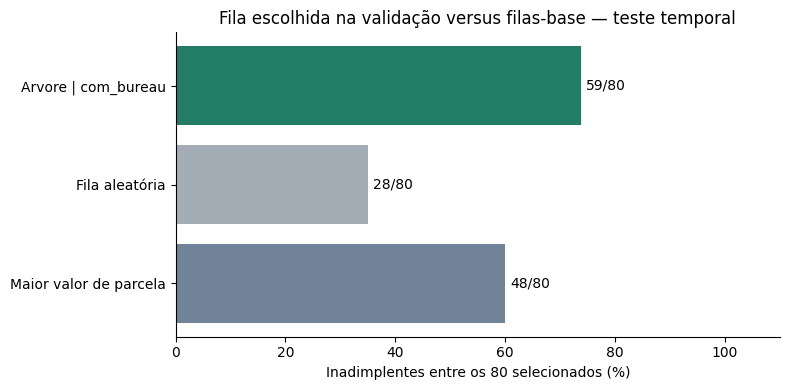

**Resposta — a fila melhora?** O modelo escolhido encontrou **59 inadimplentes entre 80**, com precision@80 de **73.8%** e recall@80 de **18.6%**. A diferença foi de **+11 contratos** em relação à maior parcela e **+31** em relação à fila aleatória desta semente. Uma fila aleatória tem expectativa de **33.7 acertos** neste teste; a realização de uma única semente pode oscilar. Não tratamos essas diferenças como teste de significância.

**Pedido de acurácia:** o resultado global no limiar 0,50 foi **64.1%** (não atinge a meta acima de 80%). Predizer sempre a classe majoritária alcançaria **57.8%**. A decisão do piloto continua apoiada na qualidade da fila de 80.

**Resposta — tradução financeira:** os **59 verdadeiros positivos** representam **R$ 70.800,00 de exposição identificada**; os **259 falsos negativos** representam **R$ 310.800,00 de exposição fora da fila**, usando a média do enunciado. A diferença frente à fila por valor da parcela corresponde a **R$ 13.200,00 de exposição adicional identificada**. Os **21 falsos positivos** ocupam 21 das 80 ligações com contratos que pagaram até D+30. Seu custo direto é **FP × custo de uma ligação**; esse custo não foi informado e não é R$ 1.200 por contato.

**Quanto se evita por semana? Ainda não foi medido.** O teste não contém intervenção nem grupo de controle e seu período não equivale a uma semana. Sob uma hipótese de conversão incremental q causada pelas ligações, a redução bruta esperada de exposição deste lote seria TP × q × R$ 1.200; o resultado líquido ainda descontaria 80 × custo de ligação, descontos de renegociação e demais custos. Não há dados para estimar q.

**Recomendação: LIGA COM RESSALVA.** O resultado justifica um piloto prospectivo controlado, condicionado a montar uma lista atual e elegível a cada semana. Reservar capacidade para um desenho com grupo de controle, medir pagamento incremental e custo real, revisar disparidades e acompanhar precision@80 depois de fechar D+30. A fila exportada abaixo é histórica, destinada à avaliação acadêmica; não é uma lista atual para ligações.

In [10]:
# TODO: precision@80, recall@80, fila-base, comparacao

rotulos_teste = y.loc[idx_teste_temporal]
ids_teste = ids.loc[idx_teste_temporal]
resultados_bases = []
rng = np.random.default_rng(SEMENTE)
scores_bases = {
    'Fila aleatória': rng.random(len(idx_teste_temporal)),
    'Maior valor de parcela': base_modelagem.loc[idx_teste_temporal, 'valor_parcela'].to_numpy(),
}
for nome, score in scores_bases.items():
    resumo = metricas_fila(rotulos_teste, score, ids_teste)
    # Prioridades das filas-base não são probabilidades estimadas.
    for coluna in ['acuracia_05', 'roc_auc', 'average_precision']:
        resumo[coluna] = np.nan
    resultados_bases.append({'candidato': nome, **resumo})
resultados_bases = pd.DataFrame(resultados_bases)
avaliacao_temporal = pd.concat([resultados_temporais, resultados_bases], ignore_index=True)
display(avaliacao_temporal[['candidato', 'n_teste', 'positivos', 'TP_80', 'FP_80', 'FN_80',
                           'precision_80', 'recall_80', 'acuracia_05']].round(4))

metricas_finais = metricas_fila(rotulos_teste, probabilidades_finais, ids_teste)
comparacao_operacional = pd.concat([
    pd.DataFrame([{'candidato': nome_escolhido, **metricas_finais}]), resultados_bases], ignore_index=True)
comparacao_operacional['exposicao_identificada_rs'] = comparacao_operacional['TP_80'] * CUSTO_REFERENCIA
comparacao_operacional['exposicao_fora_fila_rs'] = comparacao_operacional['FN_80'] * CUSTO_REFERENCIA
display(comparacao_operacional[['candidato', 'TP_80', 'FP_80', 'FN_80',
                                'exposicao_identificada_rs', 'exposicao_fora_fila_rs']])

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.barh(comparacao_operacional['candidato'], comparacao_operacional['precision_80'] * 100,
                color=['#237c65', '#a4acb5', '#718399'])
for barra, acertos in zip(barras, comparacao_operacional['TP_80']):
    ax.text(barra.get_width() + 1, barra.get_y() + barra.get_height()/2,
            f'{int(acertos)}/80', va='center')
ax.set(xlim=(0, 110), xlabel='Inadimplentes entre os 80 selecionados (%)',
       title='Fila escolhida na validação versus filas-base — teste temporal')
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

base_valor = resultados_bases.set_index('candidato').loc['Maior valor de parcela']
base_aleatoria = resultados_bases.set_index('candidato').loc['Fila aleatória']
delta_valor = metricas_finais['TP_80'] - int(base_valor['TP_80'])
delta_aleatoria = metricas_finais['TP_80'] - int(base_aleatoria['TP_80'])
prevalencia_teste = rotulos_teste.mean()
acuracia_majoritaria = max(prevalencia_teste, 1 - prevalencia_teste)
meta_atingida = metricas_finais['acuracia_05'] > 0.80
display(Markdown(
    f"**Resposta — a fila melhora?** O modelo escolhido encontrou **{metricas_finais['TP_80']} inadimplentes "
    f"entre 80**, com precision@80 de **{metricas_finais['precision_80']:.1%}** e recall@80 de "
    f"**{metricas_finais['recall_80']:.1%}**. A diferença foi de **{delta_valor:+d} contratos** em relação "
    f"à maior parcela e **{delta_aleatoria:+d}** em relação à fila aleatória desta semente. "
    f"Uma fila aleatória tem expectativa de **{K * prevalencia_teste:.1f} acertos** neste teste; "
    "a realização de uma única semente pode oscilar. Não tratamos essas diferenças como teste de significância.\n\n"
    f"**Pedido de acurácia:** o resultado global no limiar 0,50 foi **{metricas_finais['acuracia_05']:.1%}** "
    f"({'atinge' if meta_atingida else 'não atinge'} a meta acima de 80%). Predizer sempre a classe majoritária "
    f"alcançaria **{acuracia_majoritaria:.1%}**. A decisão do piloto continua apoiada na qualidade da fila de 80."
))

def reais(valor):
    return 'R$ ' + f'{valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

tp, fp, fn = (metricas_finais[chave] for chave in ['TP_80', 'FP_80', 'FN_80'])
display(Markdown(
    f"**Resposta — tradução financeira:** os **{tp} verdadeiros positivos** representam "
    f"**{reais(tp * CUSTO_REFERENCIA)} de exposição identificada**; os **{fn} falsos negativos** "
    f"representam **{reais(fn * CUSTO_REFERENCIA)} de exposição fora da fila**, usando a média do enunciado. "
    f"A diferença frente à fila por valor da parcela corresponde a **{reais(delta_valor * CUSTO_REFERENCIA)} "
    f"de exposição adicional identificada**. Os **{fp} falsos positivos** ocupam {fp} das 80 ligações "
    "com contratos que pagaram até D+30. Seu custo direto é **FP × custo de uma ligação**; esse custo "
    "não foi informado e não é R$ 1.200 por contato.\n\n"
    "**Quanto se evita por semana? Ainda não foi medido.** O teste não contém intervenção nem grupo de controle "
    "e seu período não equivale a uma semana. Sob uma hipótese de conversão incremental q causada pelas ligações, "
    "a redução bruta esperada de exposição deste lote seria TP × q × R$ 1.200; o resultado líquido ainda "
    "descontaria 80 × custo de ligação, descontos de renegociação e demais custos. Não há dados para estimar q."
))

supera_bases = metricas_finais['precision_80'] > resultados_bases['precision_80'].max()
recomendacao = 'LIGA COM RESSALVA' if supera_bases else 'NÃO LIGA AINDA COM ESTE MODELO'
display(Markdown(
    f"**Recomendação: {recomendacao}.** " +
    ("O resultado justifica um piloto prospectivo controlado, condicionado a montar uma lista atual e elegível "
     "a cada semana. Reservar capacidade para um desenho com grupo de controle, medir pagamento incremental "
     "e custo real, revisar disparidades e acompanhar precision@80 depois de fechar D+30. "
     if supera_bases else
     "O modelo não superou ambas as bases neste teste. Manter a alternativa simples como referência, "
     "revisar dados e validação em novas janelas antes de usar o ranking para orientar a cobrança. ") +
    "A fila exportada abaixo é histórica, destinada à avaliação acadêmica; não é uma lista atual para ligações."
))


### Importância das variáveis e limites de interpretação

Medimos a queda de **average precision** ao embaralhar cada variável na validação
temporal, usando o modelo ajustado somente no treino interno. Assim, esta análise
não usa o teste final para escolher ou retirar variáveis. A importance é preditiva,
não causal; variáveis correlacionadas podem compartilhar ou mascarar sua contribuição.
Valores próximos de zero ou negativos não demonstram que uma informação seja inútil
em qualquer contexto. As barras de dispersão descrevem cinco embaralhamentos, não
intervalos de confiança populacionais.


,variavel,queda_ap_media,desvio_entre_repeticoes
0,atraso_medio_anterior_dias,0.1302,0.0401
1,proporcao_atrasos_anteriores,0.1173,0.0122
2,score_bureau,0.0448,0.0068
3,atraso_maximo_anterior_dias,0.0281,0.0023
4,parcela_sobre_renda,0.0133,0.0058
5,valor_total,0.0086,0.0025
6,qtd_compras_anteriores,0.0000,0.0000
7,renda_ausente,0.0000,0.0000
8,valor_parcela,0.0000,0.0000
9,n_parcelas,0.0000,0.0000


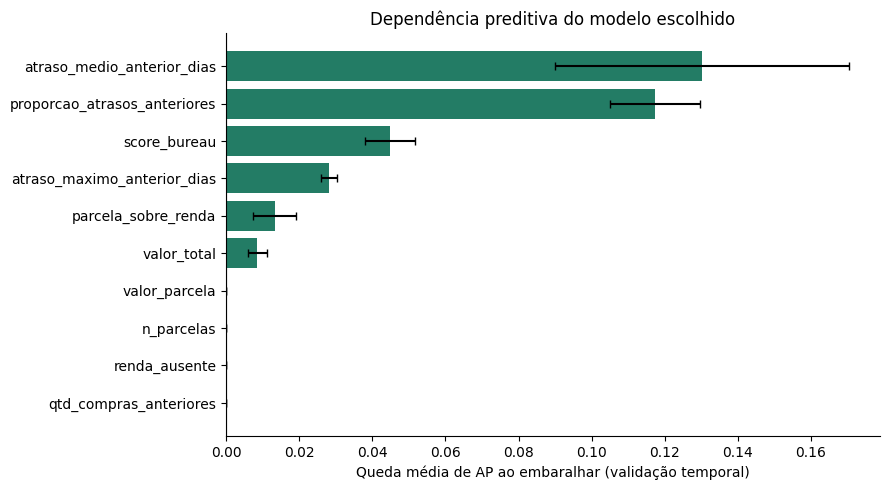

**Leitura:** as duas maiores quedas médias de AP foram associadas a **atraso_medio_anterior_dias, proporcao_atrasos_anteriores**. Isso indica dependência do modelo em relação a esses sinais nesta amostra, sem demonstrar que alterá-los mudaria o comportamento de pagamento.

**Sinal fraco neste teste:** `renda_declarada` apresentou queda média de AP de **-0.0013** ao ser embaralhada. Não há justificativa para criar uma política individual com base apenas nesse resultado. Como as features financeiras são correlacionadas e a validação é pequena, novos períodos devem confirmar a estabilidade. Nenhuma coluna foi retirada depois de olhar o teste final.

In [11]:
# TODO: importancia de variaveis - e cuidado ao interpretar

importancias = permutation_importance(
    modelos_validacao[nome_escolhido], base_modelagem.loc[idx_validacao, colunas_finais],
    y.loc[idx_validacao], scoring='average_precision', n_repeats=5, random_state=SEMENTE, n_jobs=1)
importancia_variaveis = pd.DataFrame({'variavel': colunas_finais,
                                     'queda_ap_media': importancias.importances_mean,
                                     'desvio_entre_repeticoes': importancias.importances_std})
importancia_variaveis = importancia_variaveis.sort_values('queda_ap_media', ascending=False).reset_index(drop=True)
display(importancia_variaveis.round(4))
top = importancia_variaveis.head(10).sort_values('queda_ap_media')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top['variavel'], top['queda_ap_media'], xerr=top['desvio_entre_repeticoes'], color='#237c65', capsize=3)
ax.axvline(0, color='#555555', linewidth=0.8)
ax.set(xlabel='Queda média de AP ao embaralhar (validação temporal)', title='Dependência preditiva do modelo escolhido')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()
mais_importantes = ', '.join(importancia_variaveis.head(2)['variavel'])
menos_importante = importancia_variaveis.iloc[-1]
display(Markdown(
    f"**Leitura:** as duas maiores quedas médias de AP foram associadas a **{mais_importantes}**. "
    "Isso indica dependência do modelo em relação a esses sinais nesta amostra, sem demonstrar que alterá-los "
    "mudaria o comportamento de pagamento.\n\n"
    f"**Sinal fraco neste teste:** `{menos_importante['variavel']}` apresentou queda média de AP "
    f"de **{menos_importante['queda_ap_media']:.4f}** ao ser embaralhada. "
    "Não há justificativa para criar uma política individual com base apenas nesse resultado. "
    "Como as features financeiras são correlacionadas e a validação é pequena, novos períodos devem confirmar "
    "a estabilidade. Nenhuma coluna foi retirada depois de olhar o teste final."
))


### Gerar a fila

Salve `fila_80.csv` com `id_contrato` e `probabilidade`, ordenado do maior risco para o menor.

In [12]:
# TODO: gerar fila_80.csv

ranking_final = pd.DataFrame({'id_contrato': ids_teste.to_numpy(), 'probabilidade': probabilidades_finais})
fila_80 = ranking_final.sort_values(['probabilidade', 'id_contrato'], ascending=[False, True]).head(K).reset_index(drop=True)
assert len(fila_80) == 80 and fila_80['id_contrato'].is_unique
assert fila_80['probabilidade'].between(0, 1).all()
assert fila_80['probabilidade'].is_monotonic_decreasing
assert set(fila_80['id_contrato']).issubset(set(ids_teste))
assert not set(fila_80['id_contrato']).intersection(set(ids.loc[idx_treino_temporal]))
fila_80.to_csv(CAMINHO_DADOS / 'fila_80.csv', index=False, sep=';', decimal=',', encoding='utf-8')
fila_reaberta = pd.read_csv(CAMINHO_DADOS / 'fila_80.csv', **KW)
pd.testing.assert_frame_equal(fila_80, fila_reaberta, check_exact=False, rtol=1e-12, atol=1e-12)
display(fila_80.head(10))
print(f'fila_80.csv: {len(fila_80)} contratos; modelo {nome_escolhido}.')
print('Período histórico do teste:', base_modelagem.loc[idx_teste_temporal, 'data_referencia'].min().date(),
      'até', base_modelagem.loc[idx_teste_temporal, 'data_referencia'].max().date())
print('Probabilidades usadas para ordenação: não foi realizada calibração probabilística.')


,id_contrato,probabilidade
0,C00018,0.949045
1,C00048,0.949045
2,C00053,0.949045
3,C00059,0.949045
4,C00228,0.949045
5,C00234,0.949045
6,C00245,0.949045
7,C00300,0.949045
8,C00326,0.949045
9,C00393,0.949045


fila_80.csv: 80 contratos; modelo Arvore | com_bureau.
Período histórico do teste: 2026-01-26 até 2026-02-06
Probabilidades usadas para ordenação: não foi realizada calibração probabilística.


A coluna `probabilidade` contém `predict_proba` do modelo escolhido, sem usar o alvo
para ordenar a fila. Os escores servem à priorização; não comprovamos que, por
exemplo, um valor 0,80 corresponda a 80% de risco absoluto. Os empates usam somente
o identificador e o arquivo contém exatamente as duas colunas solicitadas.


---
## Fechamento

Antes de enviar, confira o checklist da seção 9 do enunciado.

Faltam ainda dois arquivos que **não** são gerados aqui:
- `decisoes.md` — o que entrou, o que saiu, cada pedido do Ricardo respondido, e o model card.
- `apresentacao.pptx` — 3 slides, para o Ricardo, não para a banca.

> Se algum resultado ficou bom demais, pergunte: *que outra coisa poderia produzir esse mesmo número?*

### Fechamento do notebook

As cinco fases solicitadas foram implementadas. As intenções iniciais e as revisões
das fases anteriores permanecem registradas. As respostas numéricas da modelagem
e da avaliação são calculadas nas próprias células, a partir dos CSVs originais.

| Verificação | Evidência nesta versão |
|---|---|
| Alvo da parcela até D+30 | Fase 3.1, com auditoria contra o status atual. |
| Features conhecidas na previsão | Corte de todas as bases de eventos e reconstrução de pagamentos na fase 3.3. |
| Datas e categorias inspecionadas | Inventário e amostras na fase 2. |
| Uma linha por contrato e ausências coerentes | Agregações, indicadores e verificações antes de salvar `features.csv`. |
| Rótulos de treino já observados | Janela de 37 dias e exclusão de rótulos imaturos nos dois cortes temporais. |
| Modelo simples e modelos adicionais | Árvore, regressão logística e floresta, com os mesmos cortes por variante. |
| Comparação de bureau | Versões com/sem score na validação e nos testes, com diferença em pontos percentuais e acertos. |
| Fila-base, precision@80 e recall@80 | Comparação no mesmo teste temporal com fila aleatória e maior parcela. |
| Escolha sem consultar o teste final | Seleção pela validação interna e escolha congelada antes de prever o teste temporal. |
| Importância sem interpretação causal | Permutação na validação temporal, com limitações explicitadas. |
| Cinco pedidos respondidos | Intenções na fase 1, revisões na fase 3.4 e resultados de acurácia/bureau na avaliação. |
| Fila de 80 contratos | Arquivo com duas colunas, ordenação e releitura verificadas. |
| Economia estimada com honestidade | Exposição distinguida de economia; efeito causal e custo por ligação ainda desconhecidos. |

**Limites de uso:** avaliação retrospectiva de contratos, sem garantia de desempenho
em clientes novos, outras lojas, períodos futuros ou diferentes políticas de crédito.
Dados cadastrais e eventos têm as hipóteses de disponibilidade descritas na preparação.
Há poucos dados para selecionar e avaliar a fila de 80 na validação interna, e a
seleção entre seis candidatos pode variar em novas janelas. Devem ser monitorados
o desempenho, a calibração, os custos e as disparidades antes de ampliar o piloto.

O notebook gera `features.csv` e `fila_80.csv`. O documento `decisoes.md` e a
apresentação de três slides continuam como entregas externas indicadas no esqueleto;
não são gerados por este notebook. Para a entrega acadêmica completa, ainda será
necessário produzi-los e organizar o pacote solicitado no enunciado.
